# Exercise 02: DATA ACQUISITION & REPRESENTATION
Points: 6

In this exercise, we will get hands-on experience on preprocessing and analyzing the accident dataset (https://unfallatlas.statistikportal.de/ [1]). The CSV file (bremen.csv) in the folder contains accident records from the Federal State of Germany, Bremen for the year 2021. We will use pandas, shapely and folium libraries to explore the accident data.

[1] Data License Germany – Attribution – Version 2.0” or “dl-de/by-2-0” with reference to the license text at www.govdata.de/dl-de/by-2

# Installation of python packages

In [1]:
# Install pandas. To read more, https://pypi.org/project/pandas/
# Helpful for analyzing, cleaning, exploring, and manipulating data.
# !pip install pandas

In [2]:
# package for manipulation and analysis of geometric objects.
# !pip install shapely

In [3]:
#create interactive geographic visualizations
# !pip install folium

In [4]:
# !pip install matplotlib

# Analyzing accident dataset

In [5]:
# Accident dataset for Germany can be found at  https://unfallatlas.statistikportal.de/_opendata2022.html
# We preprocessed it for one region, i.e., Bremen for the year 2021
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
data=pd.read_csv("bremen.csv",header=0,sep=",") #  Specify the path of the dataset
data

,OBJECTID,State/Region,Year,Month,Hour,Day,longitude,latitude
0,21896,4,2021,9,6,5,8.625143,53.522745
1,21899,4,2021,3,5,2,8.731401,53.147276
2,21932,4,2021,6,11,6,8.817732,53.048892
3,21953,4,2021,12,13,5,8.796974,53.087160
4,21956,4,2021,5,15,2,8.861543,53.030347
...,...,...,...,...,...,...,...,...
2295,152941,4,2021,11,13,2,8.609133,53.530034
2296,152942,4,2021,9,8,6,8.734576,53.081701
2297,152943,4,2021,8,14,2,8.884495,53.053679
2298,152945,4,2021,9,21,6,8.807189,53.074102


In [6]:
data['Coordinates'] = list(zip(data.longitude, data.latitude))

In [7]:
# Point datatype from shapely
data['Coordinates'] = data['Coordinates'].apply(Point)

In [8]:
data.head()

,OBJECTID,State/Region,Year,Month,Hour,Day,longitude,latitude,Coordinates
0,21896,4,2021,9,6,5,8.625143,53.522745,POINT (8.62514303 53.52274486)
1,21899,4,2021,3,5,2,8.731401,53.147276,POINT (8.731401322 53.14727577)
2,21932,4,2021,6,11,6,8.817732,53.048892,POINT (8.817731953 53.04889245)
3,21953,4,2021,12,13,5,8.796974,53.087160,POINT (8.796974387 53.08715986)
4,21956,4,2021,5,15,2,8.861543,53.030347,POINT (8.861542872 53.03034708)


In [9]:
import folium
from folium import plugins

map = folium.Map(location = [53.07,8.807], zoom_start = 12)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in data.Coordinates ]

plugins.HeatMap(heat_data).add_to(map)

map

# Task

**Question** What do you obeserve in the above heatmap? (2 points)

Accidents are mostly concentrated on highways and main roads, with relatively few on smaller streets. Also, accidents are more frequent at intersections & roundabouts

**Question** Which months are most dangeours to drive in Bremen?(1 points)

the most dangerous months to drive in Bremen appear to be month 6 (June), 7 (July) and 10 (October)

In [10]:
month_aggregation=data.groupby(data.Month)["OBJECTID"].count().reset_index()
month_aggregation.columns=["months","count"]

<Axes: xlabel='months'>

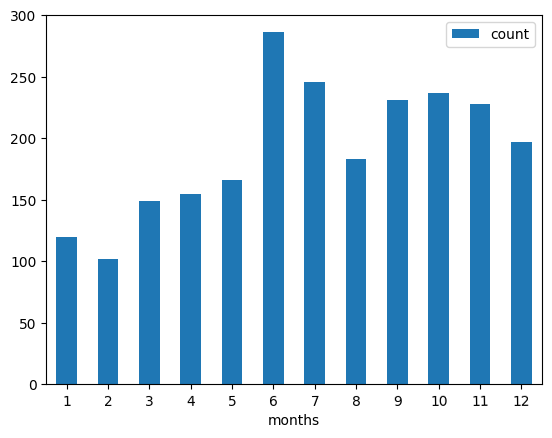

In [11]:
month_aggregation.plot.bar(x='months', y='count', rot=1)

**Question** Which days of the week are most dangerous to drive in Bremen? (1 point)

In [12]:
month_aggregation=data.groupby(data.Day)["OBJECTID"].count().reset_index()
month_aggregation.columns=["days","count"]

<Axes: xlabel='days'>

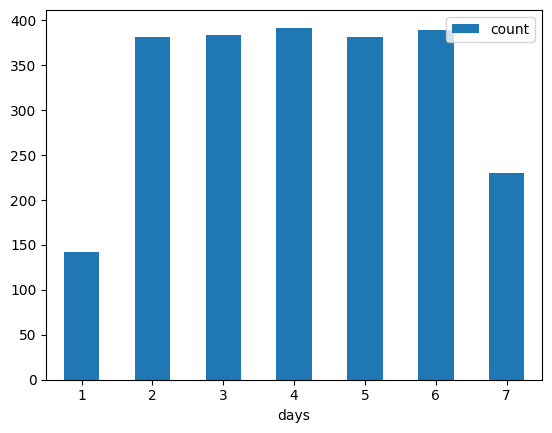

In [13]:
month_aggregation.plot.bar(x='days', y='count', rot=1)

Assumingly, day 1 and 7 are weekends (Saturday and Sunday) because they are the days with the least accidents. Therefore the most dangerous days to drive in Bremen appear to be day 4 (Wednsday), 6 (Friday) and 3 (Tuesday).

**Question** Which part of the day (morning, afternnoon, evening, night) is
most dangerous to drive in Bremen (2 points)?

  time_period  count
0   afternoon   1150
1     evening    356
2     morning    618
3       night    176


<Axes: xlabel='time_period'>

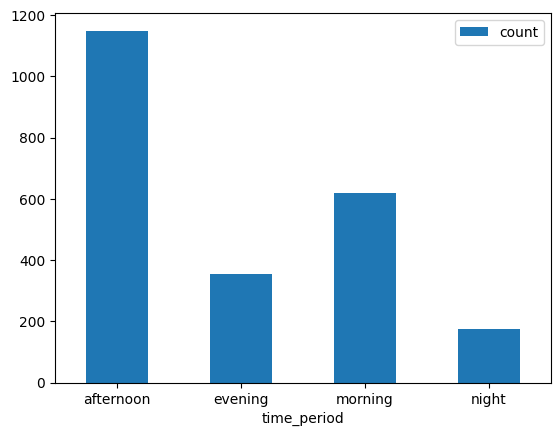

In [14]:
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 22:
        return 'evening'
    else:
        return 'night'

data['time_period'] = data['Hour'].apply(categorize_time)

time_aggregation = data.groupby('time_period')['OBJECTID'].count().reset_index()
time_aggregation.columns = ['time_period', 'count']

print(time_aggregation)

time_aggregation.plot.bar(x='time_period', y='count', rot=0)

Afternoons are the most dangerous period in the day to drive in Bremen, followed by morning. It makes sense since afternoons and mornings are rush hours times.